In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
iris = datasets.load_iris()

In [3]:
iris_data= pd.DataFrame(iris.data)

In [5]:
iris_data.columns=iris.feature_names

In [6]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled= scaler.fit_transform(iris_data)

In [9]:
##PCA
from sklearn.decomposition import PCA

In [10]:
pca = PCA(n_components=2)

In [11]:
pca_scaled = pca.fit_transform(X_scaled)

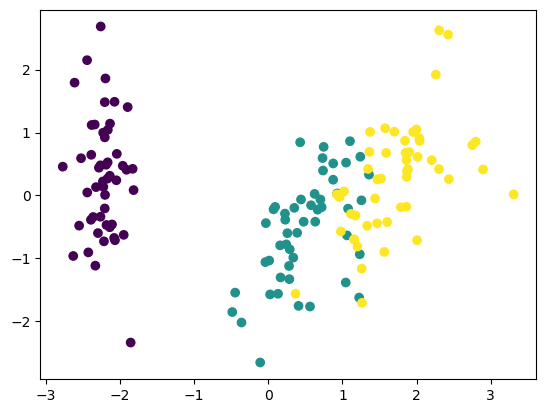

In [13]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)

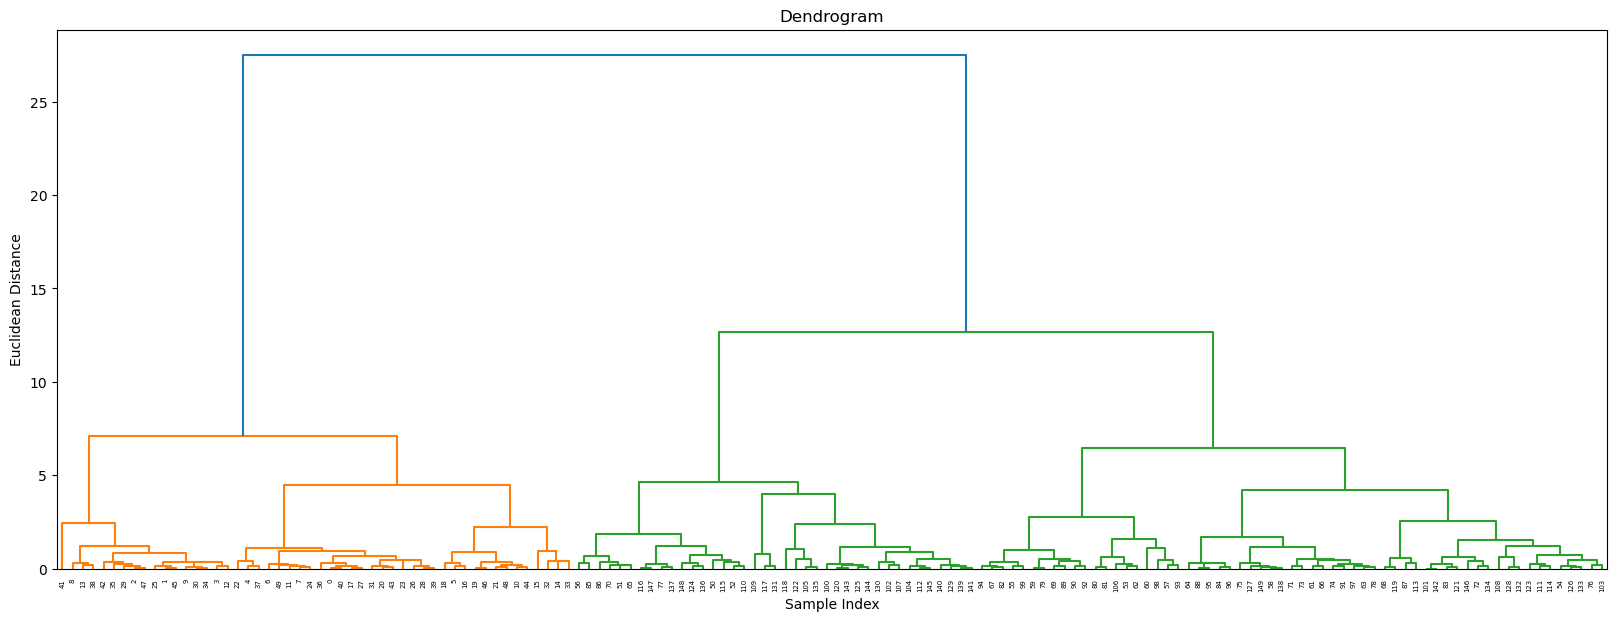

In [16]:
#Agglomerative Cluster
#Construct Dendogram
import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,7))
plt.title("Dendrogram")

sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.savefig('Dendrogram.png')
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering
cluster =AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
cluster.fit(pca_scaled)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


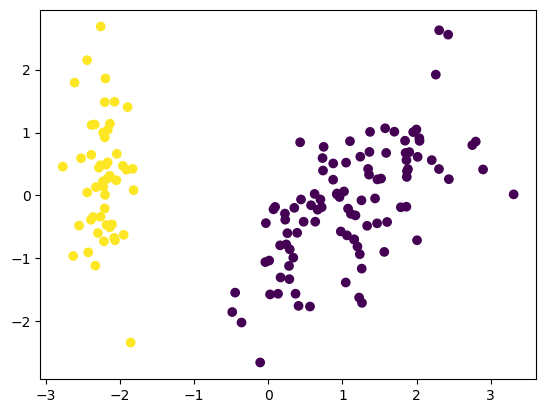

In [23]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)